In [1]:
import pandas as pd
from numpy import NaN
from pandas._libs.missing import NA

from bs4 import BeautifulSoup
import requests
import json

In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/My Folder"

Mounted at /content/drive


In [3]:
#Import datasets
df_news=pd.read_csv('/content/drive/My Drive/My Folder/cleaned_full_dataset.csv', encoding_errors='ignore')

<ipython-input-3-4596ccaebfdc>:2: DtypeWarning: Columns (0,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178) have mixed types. Specify dtype option on import or set low_memory=False.
  df_news=pd.read_csv('/content/drive/My Drive/My Folder/cleaned_full_dataset.csv', encoding_errors='ignore')


In [4]:
df_news.isnull().sum()

Unnamed: 0          0
title               2
content             0
date                0
Publisher           0
                ...  
Unnamed: 174    31489
Unnamed: 175    31489
Unnamed: 176    31489
Unnamed: 177    31489
Unnamed: 178    31489
Length: 179, dtype: int64

In [ ]:
#Remove unnamed columns/remove columns from index 16 to 178
df_news.drop(df_news.iloc[:, 16:179], inplace=True, axis=1)

In [ ]:
#Remove unnamed 0
df_news=df_news.drop(['Unnamed: 0'], axis=1)

In [ ]:
df_news

,title,content,date,Publisher,link,Label,clean_content,content_lower,content_tokenied,content_contradict,content_nodigit,lemmatized,day,month,year
0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,Last week armed men carrying machetes and othe...,last week armed men carrying machetes deadly w...,['last week armed men carrying machetes and ot...,last week armed men carrying machetes deadly w...,last week armed men carrying machetes deadly w...,week armed man carry machete deadly weapon att...,31,7,2023
1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,Amid recent coup in Niger the Chief Staff of t...,amid recent coup niger chief staff liberian ar...,['amid recent coup in niger the chief staff of...,amid recent coup niger chief staff liberian ar...,amid recent coup niger chief staff liberian ar...,amid recent coup niger chief staff liberian ar...,28,7,2023
2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,A group of unknown men said to be from Zolowee...,group unknown men said zolowee town proximity ...,['a group of unknown men said to be from zolow...,group unknown men said zolowee town proximity ...,group unknown men said zolowee town proximity ...,group unknown man say zolowee town proximity a...,30,7,2023
3,president weah commits to delivering violent ...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,Liberian President George Weah has pledged to ...,liberian president george weah pledged deliver...,['liberian president george weah has pledged t...,liberian president george weah pledged deliver...,liberian president george weah pledged deliver...,liberian president george weah pledge deliver ...,27,7,2023
4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 â€?The new World Bank ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,MONROVIA July 31 2023 â€?The new World Bank Co...,monrovia july 31 2023 â€?new world bank countr...,['monrovia july 31 2023 â€?the new world bank ...,monrovia july 31 2023 â€?new world bank countr...,monrovia july â€?new world bank country mana...,"monrovia july â?"" new world bank country ma...",31,7,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,Articles claiming the World Bank has applauded...,articles claiming world bank applauded tanzani...,['articles claiming the world bank has applaud...,articles claiming world bank applauded tanzani...,articles claiming world bank applauded tanzani...,article claim world bank applaud tanzaniaâ??s ...,21,4,2020
31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,A YouTube video shared thousands of times clai...,youtube video shared thousands times claims tw...,['a youtube video shared thousands of times cl...,youtube video shared thousands times claims tw...,youtube video shared thousands times claims tw...,youtube video share thousand time claim child ...,15,5,2020
31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,A video shared thousands of times on Facebook ...,video shared thousands times facebook purports...,['a video shared thousands of times 

In [ ]:
#Find rows where title is blank
df_title_blank=df_news[df_news['title']==' ']

In [ ]:
df_title_blank['Publisher'].unique()
df_title_blank

#News from New Dawn Liberia has missing titles

,title,content,date,Publisher,link,Label,clean_content,content_lower,content_tokenied,content_contradict,content_nodigit,lemmatized,day,month,year
4152,,By Lewis S. Teh&nbsp; The Economic Freedom Fig...,29/03/2023,New Dawn Liberia,https://thenewdawnliberia.com/liberia-faces-go...,1,\nBy Lewis S Tehnbsp\n\n\n\nThe Economic Freed...,lewis s tehnbsp economic freedom fighters libe...,['\nby lewis s tehnbsp\n\n\n\nthe economic fre...,lewis s tehnbsp economic freedom fighters libe...,lewis s tehnbsp economic freedom fighters libe...,lewis s tehnbsp economic freedom fighter liber...,29,3,2023
4153,,By Lincoln G. Peters&nbsp; Two homeless Liberi...,30/03/2023,New Dawn Liberia,https://thenewdawnliberia.com/wog-rescues-two-...,1,\nBy Lincoln G Petersnbsp\n\n\n\nTwo homeless ...,lincoln g petersnbsp two homeless liberian kid...,['\nby lincoln g petersnbsp\n\n\n\ntwo homeles...,lincoln g petersnbsp two homeless liberian kid...,lincoln g petersnbsp two homeless liberian kid...,lincoln g petersnbsp homeless liberian kid res...,30,3,2023
4154,,By Lewis S Teh The Liberia Electricity Regulat...,30/03/2023,New Dawn Liberia,https://thenewdawnliberia.com/lerc-introduces-...,1,\nBy Lewis S Teh\n\n\n\nThe Liberia Electricit...,lewis s teh liberia electricity regulatory com...,['\nby lewis s teh\n\n\n\nthe liberia electric...,lewis s teh liberia electricity regulatory com...,lewis s teh liberia electricity regulatory com...,lewis s teh liberia electricity regulatory com...,30,3,2023
4161,,"A Liberian Forensic Scientist, Dr. Rockefeller...",28/03/2023,New Dawn Liberia,https://thenewdawnliberia.com/highly-nonsensical/,1,\nA Liberian Forensic Scientist Dr Rockefeller...,liberian forensic scientist dr rockefeller f c...,['\na liberian forensic scientist dr rockefell...,liberian forensic scientist dr rockefeller f c...,liberian forensic scientist dr rockefeller f c...,liberian forensic scientist dr rockefeller f c...,28,3,2023
4170,,By Lincoln G. Peters&nbsp; Residents Nimba Cou...,27/03/2023,New Dawn Liberia,https://thenewdawnliberia.com/nimba-backs-whap...,1,\nBy Lincoln G Petersnbsp\n\n\n\nResidents of ...,lincoln g petersnbsp residents nimba county in...,['\nby lincoln g petersnbsp\n\n\n\nresidents o...,lincoln g petersnbsp residents nimba county in...,lincoln g petersnbsp residents nimba county in...,lincoln g petersnbsp resident nimba county inc...,27,3,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5572,,Stakeholders one-day forum brainstormed severa...,16/09/2022,New Dawn Liberia,https://thenewdawnliberia.com/stakeholders-bra...,1,\nStakeholders at a oneday forum have brainsto...,stakeholders oneday forum brainstormed several...,['\nstakeholders at a oneday forum have brains...,stakeholders oneday forum brainstormed several...,stakeholders oneday forum brainstormed several...,stakeholder oneday forum brainstorm step gear ...,16,9,2022
5574,,By Lincoln G. Peters A local school called Hop...,16/09/2022,New Dawn Liberia,https://thenewdawnliberia.com/local-school-lau...,1,\nBy Lincoln G Peters\n\n\n\nA local school ca...,lincoln g peters local school called hope chin...,['\nby lincoln g peters\n\n\n\na local school ...,lincoln g peters local school called hope chin...,lincoln g peters local school called hope chin...,lincoln g peters local school call hope china ...,16,9,2022
5577,,Grand Cape Mount residents complain road condi...,16/09/2022,New Dawn Liberia,https://thenewdawnliberia.com/our-lives-at-stake/,1,\nGrand Cape Mount residents complain of road ...,grand cape mount residents complain road condi...,['\ngrand cape mount residents complain of roa...,grand cape mount residents complain road condi...,grand cape mount residents complain road condi...,grand cape mount resident complain road condit...,16,9,2022
5595,,Invites NEC others clarification&nbsp; By Ethe...,14/09/2022,New Dawn Liberia,https://thenewdawnliberia.com/senate-frowns-on...,1,\nInvites NEC and others for clarificationnbsp...,invites nec others clarificationn

Rescraping news titles from New Dawn Liberia

In [ ]:
#Get all the indexes
index_missing_titles=list(df_title_blank.index)
index_missing_titles

[4152,
 4153,
 4154,
 4161,
 4170,
 4171,
 4173,
 4177,
 4186,
 4189,
 4194,
 4196,
 4199,
 4200,
 4202,
 4203,
 4204,
 4205,
 4210,
 4212,
 4213,
 4260,
 4278,
 4283,
 4288,
 4289,
 4290,
 4294,
 4331,
 4338,
 4340,
 4345,
 4348,
 4352,
 4362,
 4369,
 4370,
 4372,
 4376,
 4377,
 4382,
 4384,
 4385,
 4389,
 4399,
 4404,
 4405,
 4406,
 4412,
 4426,
 4427,
 4429,
 4436,
 4437,
 4445,
 4447,
 4449,
 4452,
 4458,
 4463,
 4466,
 4470,
 4474,
 4480,
 4483,
 4486,
 4488,
 4490,
 4508,
 4513,
 4515,
 4516,
 4518,
 4523,
 4524,
 4529,
 4532,
 4537,
 4538,
 4543,
 4544,
 4545,
 4546,
 4550,
 4556,
 4560,
 4567,
 4570,
 4576,
 4578,
 4579,
 4582,
 4585,
 4587,
 4588,
 4589,
 4590,
 4594,
 4600,
 4601,
 4604,
 4607,
 4611,
 4613,
 4617,
 4619,
 4622,
 4625,
 4626,
 4629,
 4630,
 4633,
 4634,
 4635,
 4639,
 4640,
 4644,
 4646,
 4650,
 4657,
 4658,
 4664,
 4671,
 4674,
 4675,
 4676,
 4680,
 4681,
 4684,
 4686,
 4687,
 4742,
 4743,
 4745,
 4746,
 4750,
 4791,
 4792,
 4794,
 4802,
 4810,
 4818,
 4840,

In [ ]:
#Update the title in df_news
for index, row in df_news.iterrows():
  if index in index_missing_titles:
    x=requests.get(row['link'])
    soup=BeautifulSoup(x.text, 'html.parser')
    title=soup.body.find(name='h1', attrs={'class': 'post-title entry-title'}).get_text()
    df_news.at[index, 'title']=title


KeyboardInterrupt: ignored

In [ ]:
df_news.isnull().sum()

title                   2
content                 0
date                    0
Publisher               0
link                    0
Label                   0
clean_content          71
content_lower          76
content_tokenied       61
content_contradict    146
content_nodigit       146
lemmatized            157
day                     0
month                   0
year                    0
dtype: int64

title

In [ ]:
#Find records with nan title
df_news[df_news['title'].isna()]

#3139 3140

,title,content,date,Publisher,link,Label,clean_content,content_lower,content_tokenied,content_contradict,content_nodigit,lemmatized,day,month,year
3139,NaN,The EU sends congratulations George Weah victo...,01/01/2018,Gnn News Liberia,https://gnnliberia.com/eu-congratulates-presid...,1,The EU sends its congratulations to George Wea...,eu sends congratulations george weah victory p...,['the eu sends its congratulations to george w...,eu sends congratulations george weah victory p...,eu sends congratulations george weah victory p...,eu send congratulation george weah victory pre...,1,1,2018
3140,NaN,The management Global News Network Incorporate...,01/01/2018,Gnn News Liberia,https://gnnliberia.com/gnn-liberia-wishes-brow...,1,The management of the Global News Network Inco...,management global news network incorporated pu...,['the management of the global news network in...,management global news network incorporated pu...,management global news network incorporated pu...,management global news network incorporate pub...,1,1,2018


In [ ]:
#get record 3139 record 3140 and update title
df_news.at[3139, 'title']='EU Congratulates President-Elect George Weah On His Victory'
df_news.at[3140, 'title']='GNN-Liberia Wishes All Its Browsing Public A Prosperous And Happy New Year'

In [ ]:
df_news.isnull().sum()

title                   0
content                 0
date                    0
Publisher               0
link                    0
Label                   0
clean_content          71
content_lower          76
content_tokenied       61
content_contradict    146
content_nodigit       146
lemmatized            157
day                     0
month                   0
year                    0
dtype: int64

In [ ]:
#save to csv
df_news_ori=df_news[['title', 'content', 'date', 'Publisher', 'link', 'Label', 'day', 'month', 'year']]
df_news_ori.to_csv('/content/drive/My Drive/My Folder/full_dataset_collected.csv')

In [ ]:
df_news_ori

,title,content,date,Publisher,link,Label,day,month,year
0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023
1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023
2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023
3,president weah commits to delivering violent ...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023
4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 â€?The new World Bank ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023
...,...,...,...,...,...,...,...,...,...
31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020
31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020
31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020
31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020


Text Cleaning

In [3]:
import string
import nltk
import re
import unicodedata
import lxml.html
import lxml.html.clean
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
#Import csv file of the full original dataset
df_news_ori=pd.read_csv('/content/drive/My Drive/My Folder/full_dataset_collected.csv', encoding='latin-1')

In [5]:
#Function: removve html tags
def remove_htmltags(text):
  doc=lxml.html.fromstring(text)
  cleaner=lxml.html.clean.Cleaner(style=True)
  doc=cleaner.clean_html(doc)
  text=doc.text_content()
  return text

In [12]:
#Function: remove numbers/digits
def remove_numbers(s):
  s=re.sub(r'\d+', '', str(s))
  return s

In [6]:
#Function remove accented characters
def remove_ac(text):
  text=re.sub('[¼ë½âª¹ºµ³²]','',text)
  return text

In [7]:
#Function: remove special characters
def remove_sc(text):
  removal="Ã¢â\x82¬Å\x93"+"Ã¢â\x82¬"+"\x84"+"\x83"+"\x80\x9c"+"Â\x9aÂ"+"Â\x9aÂ\x9eÂ"+"\x85"+"\\x9"+"Ë"+"©"+"ª"+"µ"+"³"+"²"+"¼"+"½"
  text=''.join(w for w in text if w not in removal)
  return text

In [8]:
#Function: remove punctuation and stopwords // tokenise
def tokenise_text(s):
  p=string.punctuation+'’”'
  s=''.join(ch for ch in s if ch not in p)
  s_tokenised=word_tokenize(s)
  s_cleaned=[w for w in s_tokenised if w.lower() not in stopwords.words('english')]
  return s_cleaned

In [9]:
#Function: converse to lowercase
def to_lowercase(words):
    """Convert all characters to lowercase from list of tokenized words"""
    new_words=[]
    for word in words:
      new_word = word.lower()
      new_words.append(new_word)
    return new_words

In [10]:
#Function: lemmatisation
def lemmatise_text(l_tokenised):
  lemmatizer=WordNetLemmatizer()
  s_lemmatised=[lemmatizer.lemmatize(word) for word in l_tokenised]
  lemmatised_text=' '.join(s_lemmatised)
  return lemmatised_text

In [14]:
s1=remove_htmltags(df_news_ori.loc[23223, 'content'])

In [15]:
s2=remove_sc(s1)

In [16]:
s2

'MONROVIA, Montserrado  The Liberia National Police says received information linking Monrovias Mayor Jefferson Koijee electoral violence reported Saturday Montserrados 13 district. On Saturday, Cornelia Kruah-Togba, running Unity Party ticket supported Alternative National Congress Liberty Party, reported live video campaign rally violently interrupted members Coalition Democratic Change, led Koijee several supporters physically wounded. Kruah-Togba said alerted one supporters stabbed death noted found young lady was. The Liberty Party political leader Grand Bassa senator, Nyonblee Karnga-Lawrence, rally directly accused mayor involved act. There reports social media mayor men possession gun cutlasses. Eyewitnesses said mayor seen walking individuals dressed military-like outfits holding cutlasses. Some said heard two gunshots violence Saturday. However, police spokesman Moses Carter told The Bush Chicken claims Koijee involved violence mere allegations.?The police earlier denied repo

In [17]:
s3=remove_numbers(s2)

In [18]:
s3

'MONROVIA, Montserrado  The Liberia National Police says received information linking Monrovias Mayor Jefferson Koijee electoral violence reported Saturday Montserrados  district. On Saturday, Cornelia Kruah-Togba, running Unity Party ticket supported Alternative National Congress Liberty Party, reported live video campaign rally violently interrupted members Coalition Democratic Change, led Koijee several supporters physically wounded. Kruah-Togba said alerted one supporters stabbed death noted found young lady was. The Liberty Party political leader Grand Bassa senator, Nyonblee Karnga-Lawrence, rally directly accused mayor involved act. There reports social media mayor men possession gun cutlasses. Eyewitnesses said mayor seen walking individuals dressed military-like outfits holding cutlasses. Some said heard two gunshots violence Saturday. However, police spokesman Moses Carter told The Bush Chicken claims Koijee involved violence mere allegations.?The police earlier denied report

In [19]:
s4=tokenise_text(s3)

In [20]:
s5=to_lowercase(s4)

In [21]:
s6=lemmatise_text(s5)

In [13]:
#clean text
df_news_ori['content_cleaned']=''
for index, r in df_news_ori.iterrows():
  s1=remove_htmltags(r['content'])
  s2=remove_sc(s1)
  s3=remove_numbers(s2)
  df_news_ori.at[index,'content_cleaned']=s3

df_news_ori

,Unnamed: 0,title,content,date,Publisher,link,Label,day,month,year,content_cleaned
0,0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ..."
1,1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a..."
2,2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit..."
3,3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv..."
4,4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ..."
...,...,...,...,...,...,...,...,...,...,...,...
31485,31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...
31486,31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...
31487,31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...
31488,31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...


In [14]:
#Tokenisation
df_news_ori['content_tokenised']=''
for index, r in df_news_ori.iterrows():
  df_news_ori.at[index,'content_tokenised']=tokenise_text(r['content_cleaned'])

df_news_ori

,Unnamed: 0,title,content,date,Publisher,link,Label,day,month,year,content_cleaned,content_tokenised
0,0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ...","[Last, week, armed, men, carrying, machetes, d..."
1,1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a...","[Amid, recent, coup, Niger, Chief, Staff, Libe..."
2,2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit...","[group, unknown, men, said, Zolowee, town, pro..."
3,3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv...","[Liberian, President, George, Weah, pledged, d..."
4,4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ...","[MONROVIA, July, new, World, Bank, Country, Ma..."
...,...,...,...,...,...,...,...,...,...,...,...,...
31485,31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...,"[Articles, claiming, World, Bank, applauded, T..."
31486,31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...,"[YouTube, video, shared, thousands, times, cla..."
31487,31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...,"[video, shared, thousands, times, Facebook, pu..."
31488,31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...,"[race, find, vaccine, novel, coronavirus, face..."


In [15]:
#Conversion to lowercase
df_news_ori['content_lowercase']=''
for index, r in df_news_ori.iterrows():
  df_news_ori.at[index,'content_lowercase']=to_lowercase(r['content_tokenised'])

df_news_ori

,Unnamed: 0,title,content,date,Publisher,link,Label,day,month,year,content_cleaned,content_tokenised,content_lowercase
0,0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ...","[Last, week, armed, men, carrying, machetes, d...","[last, week, armed, men, carrying, machetes, d..."
1,1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a...","[Amid, recent, coup, Niger, Chief, Staff, Libe...","[amid, recent, coup, niger, chief, staff, libe..."
2,2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit...","[group, unknown, men, said, Zolowee, town, pro...","[group, unknown, men, said, zolowee, town, pro..."
3,3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv...","[Liberian, President, George, Weah, pledged, d...","[liberian, president, george, weah, pledged, d..."
4,4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ...","[MONROVIA, July, new, World, Bank, Country, Ma...","[monrovia, july, new, world, bank, country, ma..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31485,31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...,"[Articles, claiming, World, Bank, applauded, T...","[articles, claiming, world, bank, applauded, t..."
31486,31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...,"[YouTube, video, shared, thousands, times, cla...","[youtube, video, shared, thousands, times, cla..."
31487,31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...,"[video, shared, thousands, times, Facebook, pu...","[video, shared, thousands, times, facebook, pu..."
31488,31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...,"[race, find, vaccine, novel, coronavirus, face...","[race, find, vaccine, novel, coronavirus, face..."


In [16]:
#Lemmatisation
df_news_ori['content_lemmatised']=''
for index, r in df_news_ori.iterrows():
  df_news_ori.at[index,'content_lemmatised']=lemmatise_text(r['content_lowercase'])

df_news_ori

,Unnamed: 0,title,content,date,Publisher,link,Label,day,month,year,content_cleaned,content_tokenised,content_lowercase,content_lemmatised
0,0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ...","[Last, week, armed, men, carrying, machetes, d...","[last, week, armed, men, carrying, machetes, d...",last week armed men carrying machete deadly we...
1,1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a...","[Amid, recent, coup, Niger, Chief, Staff, Libe...","[amid, recent, coup, niger, chief, staff, libe...",amid recent coup niger chief staff liberian ar...
2,2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit...","[group, unknown, men, said, Zolowee, town, pro...","[group, unknown, men, said, zolowee, town, pro...",group unknown men said zolowee town proimity a...
3,3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv...","[Liberian, President, George, Weah, pledged, d...","[liberian, president, george, weah, pledged, d...",liberian president george weah pledged deliver...
4,4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ...","[MONROVIA, July, new, World, Bank, Country, Ma...","[monrovia, july, new, world, bank, country, ma...",monrovia july new world bank country manager l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31485,31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...,"[Articles, claiming, World, Bank, applauded, T...","[articles, claiming, world, bank, applauded, t...",article claiming world bank applauded tanzania...
31486,31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...,"[YouTube, video, shared, thousands, times, cla...","[youtube, video, shared, thousands, times, cla...",youtube video shared thousand time claim two c...
31487,31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...,"[video, shared, thousands, times, Facebook, pu...","[video, shared, thousands, times, facebook, pu...",video shared thousand time facebook purport sh...
31488,31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...,"[race, find, vaccine, novel, coronavirus, face...","[race, find, vaccine, novel, coronavirus, face...",race find vaccine novel coronavirus face uphil...


In [ ]:
#save to csv
df_news_ori.to_csv('/content/drive/My Drive/My Folder/updated_full_dataset.csv')

In [17]:
#df_news[df_news['content_cleaned']=='']
df_news_ori=df_news_ori.drop(df_news_ori[df_news_ori['content_cleaned']==''].index)
df_news_ori=df_news_ori.drop(df_news_ori[df_news_ori['content_cleaned']==' '].index)


In [18]:
#Remove rows that contain missing data
for index, r in df_news_ori.iterrows():
  if len(r['content_tokenised'])==0:
    df_news_ori=df_news_ori.drop(index)

# EDA

In [19]:
import plotly.express as px
import plotly.graph_objects as go
import nltk
nltk.download('averaged_perceptron_tagger')
from collections import Counter

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [20]:
df_news=df_news_ori

In [21]:
df_news

,Unnamed: 0,title,content,date,Publisher,link,Label,day,month,year,content_cleaned,content_tokenised,content_lowercase,content_lemmatised
0,0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ...","[Last, week, armed, men, carrying, machetes, d...","[last, week, armed, men, carrying, machetes, d...",last week armed men carrying machete deadly we...
1,1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a...","[Amid, recent, coup, Niger, Chief, Staff, Libe...","[amid, recent, coup, niger, chief, staff, libe...",amid recent coup niger chief staff liberian ar...
2,2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit...","[group, unknown, men, said, Zolowee, town, pro...","[group, unknown, men, said, zolowee, town, pro...",group unknown men said zolowee town proimity a...
3,3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv...","[Liberian, President, George, Weah, pledged, d...","[liberian, president, george, weah, pledged, d...",liberian president george weah pledged deliver...
4,4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ...","[MONROVIA, July, new, World, Bank, Country, Ma...","[monrovia, july, new, world, bank, country, ma...",monrovia july new world bank country manager l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31485,31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...,"[Articles, claiming, World, Bank, applauded, T...","[articles, claiming, world, bank, applauded, t...",article claiming world bank applauded tanzania...
31486,31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...,"[YouTube, video, shared, thousands, times, cla...","[youtube, video, shared, thousands, times, cla...",youtube video shared thousand time claim two c...
31487,31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...,"[video, shared, thousands, times, Facebook, pu...","[video, shared, thousands, times, facebook, pu...",video shared thousand time facebook purport sh...
31488,31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...,"[race, find, vaccine, novel, coronavirus, face...","[race, find, vaccine, novel, coronavirus, face...",race find vaccine novel coronavirus face uphil...


In [22]:
#remove unnamed columns
#Remove unnamed 0
df_news=df_news.drop(['Unnamed: 0'], axis=1)

News Collection Count by Years

In [23]:
#Visualise the news count by year
date_count=df_news['year'].value_counts()
fig=px.histogram(df_news, x='year', title='News Count by Year', color='Label', color_discrete_sequence=["#676FA3", "#FF5959"])
fig.update_xaxes(title='Publication Year').update_yaxes(title='News Count')
fig.update_layout(width=1000, height=500, bargap=0.03)
fig.show()

In [24]:
#Ratio of fake and real news
r_real=round((df_news['Label'].value_counts()[1])/len(df_news), 3)
r_fake=round((df_news['Label'].value_counts()[0])/len(df_news), 3)
print('The ratio of fake and real news: \n')
print('Real news:{}\nFake news:{}'.format(r_real, r_fake))

The ratio of fake and real news: 

Real news:0.828
Fake news:0.172


In [25]:
#Visualise the number of fake and real news
#label_count=df_news['Label (Fake-0| True-1)'].value_counts()
fig=px.histogram(df_news, x='Label', title='Distribution of fake and factual news', color='Label', color_discrete_sequence=["#676FA3", "#FF5959"])
fig.update_xaxes(type='category', title='News Label').update_yaxes(title='News Count')
fig.update_layout(width=1000, height=500, bargap=0.03)
fig.show()

In [26]:
#Visualise news lenght count
df_news['content_length']=''
for index, r in df_news.iterrows():
  df_news.at[index,'content_length']=len(r['content_cleaned'])

fig=px.histogram(df_news, x='content_length', title='News Text Length Count', barmode='overlay', color='Label', color_discrete_sequence=["#676FA3", "#FF5959"])
fig.update_xaxes(title='Text length').update_yaxes(title='News Count')
fig.update_layout(width=1400, height=500)
fig.show()

In [27]:
#calculation the number of words and the average length of words
df_news['word_count']=''
df_news['aver_word_length']=''

for index, r in df_news.iterrows():
  words=r['content_cleaned'].split()
  df_news.at[index, 'word_count']=len(words)
  df_news.at[index,'aver_word_length']=sum(len(word) for word in words)/len(words)

In [28]:
fig=px.histogram(df_news, x='word_count', title='The number of words', barmode='overlay', color='Label', color_discrete_sequence=["#676FA3", "#FF5959"])
#fig.update_xaxes(title='Average Word length').update_yaxes(title='News Count')
fig.update_layout(width=1400, height=500)
fig.show()

In [29]:
#visualisation
fig=px.histogram(df_news, x='aver_word_length', title='Average Word Length Count', barmode='overlay', color='Label', color_discrete_sequence=["#676FA3", "#FF5959"])
#fig.update_xaxes(title='Average Word length').update_yaxes(title='News Count')
fig.update_layout(width=1400, height=500)
fig.show()

In [30]:
df_news

,title,content,date,Publisher,link,Label,day,month,year,content_cleaned,content_tokenised,content_lowercase,content_lemmatised,content_length,word_count,aver_word_length
0,government must provide security for aml in th...,"Last week, armed men carrying machetes deadly ...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/government-must-provide...,1,31,7,2023,"Last week, armed men carrying machetes deadly ...","[Last, week, armed, men, carrying, machetes, d...","[last, week, armed, men, carrying, machetes, d...",last week armed men carrying machete deadly we...,2409,307,6.850163
1,liberia army chief of staff predicts unforesee...,"Amid recent coup Niger, Chief Staff Liberian a...",28/07/2023,Gnn News Liberia,https://gnnliberia.com/liberia-army-chief-of-s...,1,28,7,2023,"Amid recent coup Niger, Chief Staff Liberian a...","[Amid, recent, coup, Niger, Chief, Staff, Libe...","[amid, recent, coup, niger, chief, staff, libe...",amid recent coup niger chief staff liberian ar...,2232,293,6.617747
2,guns machetes men attack vandalize arcelormit...,"A group unknown men said Zolowee, town proximi...",30/07/2023,Gnn News Liberia,https://gnnliberia.com/guns-machetes-men-attac...,1,30,7,2023,"A group unknown men said Zolowee, town proimit...","[group, unknown, men, said, Zolowee, town, pro...","[group, unknown, men, said, zolowee, town, pro...",group unknown men said zolowee town proimity a...,2015,268,6.511194
3,president Â weah commits to delivering violent...,"Liberian President, George Weah, pledged deliv...",27/07/2023,Gnn News Liberia,https://gnnliberia.com/president-weah-commits-...,1,27,7,2023,"Liberian President, George Weah, pledged deliv...","[Liberian, President, George, Weah, pledged, d...","[liberian, president, george, weah, pledged, d...",liberian president george weah pledged deliver...,2341,291,7.044674
4,new world bank liberia country manager arrives,"MONROVIA, July 31, 2023 Ã¢â¬?The new World Ba...",31/07/2023,Gnn News Liberia,https://gnnliberia.com/new-world-bank-liberia-...,1,31,7,2023,"MONROVIA, July , ?The new World Bank Country ...","[MONROVIA, July, new, World, Bank, Country, Ma...","[monrovia, july, new, world, bank, country, ma...",monrovia july new world bank country manager l...,1216,151,7.046358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31485,the world bank did not praise tanzanias antico...,Articles claiming World Bank applauded Tanzani...,21/04/2020 18:24,Afp Fact check,https://factcheck.afp.com/world-bank-did-not-p...,0,21,4,2020,Articles claiming World Bank applauded Tanzani...,"[Articles, claiming, World, Bank, applauded, T...","[articles, claiming, world, bank, applauded, t...",article claiming world bank applauded tanzania...,3334,427,6.803279
31486,tv report shows an unrelated guinea incident p...,A YouTube video shared thousands times claims ...,15/05/2020 15:11,Afp Fact check,https://factcheck.afp.com/tv-report-shows-unre...,0,15,5,2020,A YouTube video shared thousands times claims ...,"[YouTube, video, shared, thousands, times, cla...","[youtube, video, shared, thousands, times, cla...",youtube video shared thousand time claim two c...,3724,510,6.290196
31487,this video shows a flypast rehearsal for south...,A video shared thousands times Facebook purpor...,04/05/2020 18:04,Afp Fact check,https://factcheck.afp.com/video-shows-flypast-...,0,4,5,2020,A video shared thousands times Facebook purpor...,"[video, shared, thousands, times, Facebook, pu...","[video, shared, thousands, times, facebook, pu...",video shared thousand time facebook purport sh...,1363,184,6.407609
31488,african mistrust of western vaccines threatens...,The race find vaccine novel coronavirus faces ...,05/05/2020 17:02,Afp Fact check,https://factcheck.afp.com/african-mistrust-wes...,0,5,5,2020,The race find vaccine novel coronavirus faces ...,"[race, find, vaccine, novel, coronavirus, face...","[race, find, vaccine, novel, coronavirus, face...",race find vaccine novel coronavirus face uphil...,6893,897,

In [82]:
#Save to csv
df_news.to_csv("/content/drive/My Drive/My Folder/detailed_full_dataset.csv")

In [90]:
df_dataset_calculation=df_news[['Label','year','content_length','word_count','aver_word_length']]
df_dataset_calculation
df_dataset_calculation.to_csv("/content/drive/My Drive/My Folder/dataset_calculation.csv")

Word Cloud for fake news

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
df_news.loc[0]['content_cleaned']

'Last week, armed men carrying machetes deadly weapons attacked ArcelorMittals Tokadeh Mines Yekepa shot employee. The violent attack masterminded gang criminals said stationed town Zolowee within confines ArcelorMittals operational area Nimba County. The criminals earlier opened fire police officers town officers discovered warehouse stolen fuel oil yellow machines spare parts. They flogged Segal private security guards duty damaged vehicle attack Tokadeh Mines ArcelorMittal Liberia (AML) confirmed situation will continue work ensure safety wellbeing emplyoees remain top priority. Since volent gangs attack, mounting fear uncertainty engulfed communities around ArcelorMittals mining site Nimba County People Zolowee Town gang opened gun fire Police officers beat private security guards even terrified given shock last weeks events. What disturbing fact first kind company come repeated attacks criminal gangs. The government Liberia will step immediately provide security biggest foreign di

In [ ]:
input=''
for index, row in df_news.iterrows():
  if row['Label']==0:
    input=input+row['content_lemmatised']

In [ ]:
#Creating empty WordCloud object and generating actual WordCloud.
wordcloud=WordCloud().generate(input)

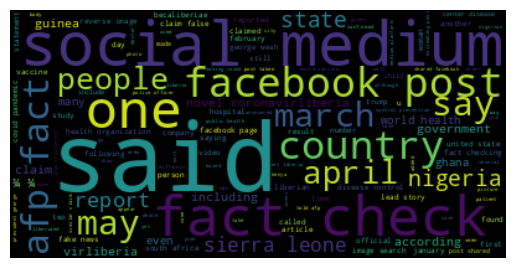

In [ ]:
#Display the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

POS Tag Counts

In [ ]:
def get_post_tags_list(tokenised_text):
  all_pos_tags=[]
  for word in tokenised_text:
    pos_tag=nltk.pos_tag([word])[0][1]
    all_pos_tags.append(pos_tag)
  return all_pos_tags

In [ ]:
#Get pos_tag of all fake news
pos_tag_fake=[]
pos_tag_real=[]
for index, r in df_news.iterrows():
  if r['Label']==0:
    for w in r['content_tokenised']:
      pos_tag_f=nltk.pos_tag([w])
      pos_tag_fake.append(pos_tag_f)
  if r['Label']==1:
    for w in r['content_tokenised']:
      pos_tag_r=nltk.pos_tag([w])
      pos_tag_real.append(pos_tag_r)


In [ ]:
#Function: count the occurrence of different tags in both fake and real news dataset
def get_pos_tag_count(pos_tag_list):
  tags=[]
  from collections import Counter
  for item in pos_tag_list:
    tags.append(item[0][1])
  tag_counts=Counter(tags)
  return tag_counts

In [ ]:
#Function: count the occurrence of different words in both fake and real news dataset
def get_word_count(pos_tag_list):
  words=[]
  from collections import Counter
  for item in pos_tag_list:
    words.append(item[0][0])
  word_counts=Counter(words)
  return word_counts

word frequency in fake news

In [ ]:
df_word_fake=pd.DataFrame(list(get_word_count(pos_tag_fake).items()), columns=['word', 'frequency'])
df_word_fake['frequency_ratio']=100*(df_word_fake['frequency']/sum(df_word_fake['frequency']))
df_word_fake['news_category']=0
df_word_fake

,word,frequency,frequency_ratio,news_category
0,Posting,4,0.000215,0
1,Country,48,0.002585,0
2,ZA,1,0.000054,0
3,Full,55,0.002962,0
4,Time,75,0.004039,0
...,...,...,...,...
96127,Neguede,1,0.000054,0
96128,julius,1,0.000054,0
96129,malema,1,0.000054,0
96130,Siolise,1,0.000054,0


In [ ]:
df_word_fake.to_csv("/content/drive/My Drive/My Folder/word_freq_fake.csv")

word frequency in real news

In [ ]:
df_word_real=pd.DataFrame(list(get_word_count(pos_tag_real).items()), columns=['word', 'frequency'])
df_word_real['frequency_ratio']=100*(df_word_real['frequency']/sum(df_word_real['frequency']))
df_word_real['news_category']=1
df_word_real

,word,frequency,frequency_ratio,news_category
0,Last,546,0.007162,1
1,week,2921,0.038316,1
2,armed,1354,0.017761,1
3,men,2754,0.036126,1
4,carrying,915,0.012003,1
...,...,...,...,...
204527,DubawaNG,1,0.000013,1
204528,DubawaGH,1,0.000013,1
204529,DubawaSLFacebook,1,0.000013,1
204530,DubawaInstagram,1,0.000013,1


In [ ]:
df_word_fake.to_csv("/content/drive/My Drive/My Folder/word_freq_real.csv")

In [ ]:
#Concatnate two dataframes
df_word=pd.concat([df_word_real, df_word_fake])

In [ ]:
df_word

,word,frequency,frequency_ratio,news_category
0,Last,546,0.007162,1
1,week,2921,0.038316,1
2,armed,1354,0.017761,1
3,men,2754,0.036126,1
4,carrying,915,0.012003,1
...,...,...,...,...
96127,Neguede,1,0.000054,0
96128,julius,1,0.000054,0
96129,malema,1,0.000054,0
96130,Siolise,1,0.000054,0


In [ ]:
#Visualise the most frequent words in fake news
fig=px.histogram(df_word_fake[df_word_fake['frequency_ratio']>0.01], x='word', y='frequency_ratio', title='Word Frequency in Fake News')
#fig=px.pie(df_word_fake[df_word_fake['frequency_ratio']>0.45], names='word', values='frequency_ratio', title='Word Frequency in Fake News')
#fig.update_xaxes(title='Average Word length').update_yaxes(title='News Count')
fig.update_layout(xaxis={'categoryorder':'total descending'}, width=1400, height=500)
fig.show()

In [ ]:
#Visualise the most frequent words in real news
fig=px.histogram(df_word_real[df_word_real['frequency_ratio']>0.01], x='word', y='frequency_ratio', title='Word Frequency in Fake News')
#fig=px.pie(df_word_real[df_word_real['frequency_ratio']>0.37], names='word', values='frequency_ratio', title='Word Frequency in Real News')
#fig.update_xaxes(title='Average Word length').update_yaxes(title='News Count')
fig.update_layout(xaxis={'categoryorder':'total descending'}, width=1400, height=500)
fig.show()

In [ ]:
df_word_real.to_csv("/content/drive/My Drive/My Folder/word_freq_real.csv")

pos tag in fake news

In [ ]:
df_pos_tag_fake=pd.DataFrame(list(get_pos_tag_count(pos_tag_fake).items()), columns=['pos_tag', 'frequency'])
df_pos_tag_fake['frequency_ratio']=100*(df_pos_tag_fake['frequency']/sum(df_pos_tag_fake['frequency']))
df_pos_tag_fake['news_category']=0
df_pos_tag_fake

,pos_tag,frequency,frequency_ratio,news_category
0,VBG,75630,4.073154,0
1,NN,948150,51.063878,0
2,NNS,293530,15.808448,0
3,JJ,140307,7.556420,0
4,RB,61900,3.333707,0
5,PRP,658,0.035437,0
6,VB,28916,1.557310,0
7,VBN,119751,6.449349,0
8,JJS,4341,0.233790,0
9,IN,17708,0.953688,0


pos tag in real news

In [ ]:
df_pos_tag_real=pd.DataFrame(list(get_pos_tag_count(pos_tag_real).items()), columns=['pos_tag', 'frequency'])
df_pos_tag_real['frequency_ratio']=100*(df_pos_tag_real['frequency']/sum(df_pos_tag_real['frequency']))
df_pos_tag_real['news_category']=1
df_pos_tag_real

,pos_tag,frequency,frequency_ratio,news_category
0,JJ,622305,8.163109,1
1,NN,3794115,49.769446,1
2,VBN,434874,5.704476,1
3,NNS,1170352,15.352136,1
4,VBG,340700,4.469145,1
5,RB,230769,3.027121,1
6,VBD,144938,1.901230,1
7,IN,76261,1.000357,1
8,NNP,527536,6.919973,1
9,RBR,8652,0.113493,1


In [ ]:
#Concatenate two DataFrames
df_pos_tag=pd.concat([df_pos_tag_real, df_pos_tag_fake])
df_pos_tag

,pos_tag,frequency,frequency_ratio,news_category
0,JJ,622305,8.163109,1
1,NN,3794115,49.769446,1
2,VBN,434874,5.704476,1
3,NNS,1170352,15.352136,1
4,VBG,340700,4.469145,1
5,RB,230769,3.027121,1
6,VBD,144938,1.901230,1
7,IN,76261,1.000357,1
8,NNP,527536,6.919973,1
9,RBR,8652,0.113493,1


In [ ]:
#save to csv
df_pos_tag.to_csv('/content/drive/My Drive/My Folder/pos_tag.csv')

In [ ]:
#Get the most frequent proper nouns in real news
nnpwords_real=[]
for item in pos_tag_real:
  if item[0][1] in ['NNP', 'NNPS']:
    nnpwords_real.append(item[0][0])
nnp_real=Counter(nnpwords_real)
nnp_real.most_common(100)

[('President', 33291),
 ('County', 23345),
 ('National', 18297),
 ('Minister', 13201),
 ('Ministry', 12676),
 ('United', 11291),
 ('Africa', 10486),
 ('George', 9554),
 ('Grand', 8533),
 ('Johnson', 7955),
 ('Commission', 7783),
 ('Court', 7491),
 ('Party', 7344),
 ('Development', 7208),
 ('Senate', 6122),
 ('Bank', 6050),
 ('Health', 5996),
 ('NEC', 5952),
 ('House', 5861),
 ('General', 5729),
 ('CDC', 5713),
 ('International', 5450),
 ('District', 5411),
 ('October', 5153),
 ('Vice', 4855),
 ('University', 4684),
 ('Tuesday', 4589),
 ('Monday', 4349),
 ('June', 4296),
 ('Media', 4216),
 ('Union', 4149),
 ('July', 4036),
 ('December', 4000),
 ('Chairman', 3983),
 ('City', 3894),
 ('March', 3831),
 ('Joseph', 3738),
 ('Winston', 3716),
 ('Thursday', 3699),
 ('Community', 3695),
 ('Wednesday', 3678),
 ('West', 3613),
 ('Supreme', 3553),
 ('Center', 3495),
 ('Committee', 3478),
 ('Association', 3342),
 ('January', 3285),
 ('May', 3278),
 ('April', 3244),
 ('September', 3184),
 ('August',

In [ ]:
#Save to dataframe
df_nnp_real=pd.DataFrame(nnp_real.most_common(212))
df_nnp_real['news_category']=1
df_nnp_real=df_nnp_real.rename(columns={0:'NNP', 1:'frequency'})
df_nnp_real['frequency_ratio']=(df_nnp_real['frequency']/len(nnpwords_real))*100

#Drop month proper nouns
import calendar
month_name=list(calendar.month_name)[1::]
df_nnp_real=df_nnp_real.loc[~df_nnp_real['NNP'].isin(month_name)]

df_nnp_real

,NNP,frequency,news_category,frequency_ratio
0,President,33291,1,6.310037
1,County,23345,1,4.424854
2,National,18297,1,3.468047
3,Minister,13201,1,2.502142
4,Ministry,12676,1,2.402632
...,...,...,...,...
207,Kogar,233,1,0.044163
208,Aaron,220,1,0.041699
209,Wesley,219,1,0.041510
210,UNESCO,216,1,0.040941


In [ ]:
#Get the most frequent proper nouns in fake news
nnpwords_fake=[]
for item in pos_tag_fake:
  if item[0][1] in ['NNP', 'NNPS']:
    nnpwords_fake.append(item[0][0])
nnp_fake=Counter(nnpwords_fake)
nnp_fake.most_common(100)

[('March', 5461),
 ('April', 4280),
 ('Health', 3517),
 ('May', 2935),
 ('President', 2898),
 ('Africa', 2178),
 ('South', 1889),
 ('February', 1732),
 ('July', 1697),
 ('National', 1635),
 ('Ghana', 1612),
 ('June', 1595),
 ('University', 1558),
 ('United', 1481),
 ('January', 1412),
 ('CDC', 1175),
 ('Media', 1171),
 ('George', 1044),
 ('Department', 1019),
 ('November', 946),
 ('ANC', 930),
 ('International', 915),
 ('August', 894),
 ('October', 888),
 ('Social', 874),
 ('December', 867),
 ('September', 849),
 ('Kenya', 845),
 ('Minister', 818),
 ('Center', 752),
 ('New', 706),
 ('Buhari', 609),
 ('Institute', 606),
 ('Johnson', 593),
 ('Act', 592),
 ('White', 588),
 ('Party', 578),
 ('Ministry', 553),
 ('City', 523),
 ('District', 486),
 ('Service', 474),
 ('Congress', 469),
 ('Washington', 460),
 ('Group', 448),
 ('West', 444),
 ('Court', 437),
 ('Journal', 425),
 ('Bank', 418),
 ('Commission', 412),
 ('County', 409),
 ('Development', 381),
 ('Peter', 371),
 ('Kenyan', 360),
 ('Mo

In [ ]:
#Save to dataframe
df_nnp_fake=pd.DataFrame(nnp_fake.most_common(212))
df_nnp_fake['news_category']=0
df_nnp_fake=df_nnp_fake.rename(columns={0:'NNP', 1:'frequency'})
df_nnp_fake['frequency_ratio']=(-df_nnp_fake['frequency']/len(nnpwords_fake))*100

#Drop month proper nouns
df_nnp_fake=df_nnp_fake.loc[~df_nnp_fake['NNP'].isin(month_name)]

df_nnp_fake

,NNP,frequency,news_category,frequency_ratio
2,Health,3517,0,-3.551270
4,President,2898,0,-2.926238
5,Africa,2178,0,-2.199222
6,South,1889,0,-1.907406
9,National,1635,0,-1.650931
...,...,...,...,...
207,Vanguard,56,0,-0.056546
208,McConnell,56,0,-0.056546
209,Taiwan,55,0,-0.055536
210,Atlantic,55,0,-0.055536


In [ ]:
#Concatenate 2 dataframes
df_nnp=pd.concat([df_nnp_real, df_nnp_fake])
df_nnp

,NNP,frequency,news_category,frequency_ratio
0,President,33291,1,6.310037
1,County,23345,1,4.424854
2,National,18297,1,3.468047
3,Minister,13201,1,2.502142
4,Ministry,12676,1,2.402632
...,...,...,...,...
207,Vanguard,56,0,-0.056546
208,McConnell,56,0,-0.056546
209,Taiwan,55,0,-0.055536
210,Atlantic,55,0,-0.055536


In [ ]:
#Reset index
df_nnp=df_nnp.reset_index()
df_nnp=df_nnp.drop(['index'], axis=1)
df_nnp

,NNP,frequency,news_category,frequency_ratio
0,President,33291,1,6.310037
1,County,23345,1,4.424854
2,National,18297,1,3.468047
3,Minister,13201,1,2.502142
4,Ministry,12676,1,2.402632
...,...,...,...,...
395,Vanguard,56,0,-0.056546
396,McConnell,56,0,-0.056546
397,Taiwan,55,0,-0.055536
398,Atlantic,55,0,-0.055536


In [ ]:
#Save to csv
df_nnp.to_csv("/content/drive/My Drive/My Folder/nnp_200.csv")

**TF-IDF**


In [31]:
print("The number of words in fake news is: " +str(len(df_word_fake)))
print("The number of words in real news is: " +str(len(df_word_real)))
print("There are {} words with frequency >= 0.05 in fake news.".format(len(df_word_fake[df_word_fake['frequency_ratio']>=0.01])))
print("There are {} words with frequency >= 0.05 in real news.".format(len(df_word_real[df_word_real['frequency_ratio']>=0.01])))

NameError: ignored

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(min_df=0.1, stop_words='english')

In [80]:
df_news_0=[df_news.loc[0]['content_lemmatised'],'']

In [26]:
response=vectorizer.fit_transform(df_news_0)
df_tfidf_sklearn=pd.DataFrame(response.toarray(),columns=vectorizer.get_feature_names_out())
df_tfidf_sklearn.loc[0]

NameError: ignored

In [38]:
response=vectorizer.fit_transform(list(df_news['content_lemmatised']))
df_tfidf_sklearn=pd.DataFrame(response.toarray(),columns=vectorizer.get_feature_names_out())
df_tfidf_sklearn

,access,according,act,action,activity,added,adding,address,administration,affair,...,way,weah,wednesday,week,winston,woman,work,working,world,year
0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.131414,0.0,0.000000,0.052808,0.000000,0.000000,0.086902
1,0.000000,0.044727,0.0,0.000000,0.000000,0.071203,0.071613,0.000000,0.0,0.232038,...,0.065807,0.000000,0.080159,0.000000,0.0,0.069962,0.056884,0.070623,0.000000,0.000000
2,0.000000,0.000000,0.0,0.000000,0.000000,0.090474,0.090995,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.072280,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.0,0.000000,0.000000,0.069837,0.000000,0.000000,0.0,0.000000,...,0.000000,0.246123,0.078621,0.000000,0.0,0.000000,0.055793,0.000000,0.000000,0.137720
4,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.181567,0.000000,0.099283,0.074697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31402,0.000000,0.027806,0.0,0.084623,0.047323,0.000000,0.000000,0.049683,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.070728,0.000000,0.425424,0.000000
31403,0.000000,0.077112,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.037818,0.000000,0.000000,0.000000,0.0,0.040206,0.000000,0.000000,0.035751,0.053796
31404,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.234890
31405,0.040595,0.023147,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.034056,0.000000,0.000000,0.036629,0.0,0.072412,0.029438,0.000000,0.128776,0.024222


In [39]:
df_tfidf_sklearn.to_csv("/content/drive/My Drive/My Folder/tf_idf_matrix.csv")

In [42]:
df_tfidf_sklearn=pd.read_csv("/content/drive/My Drive/My Folder/tf_idf_matrix.csv")

Deal with imbalanced dataset

Oversampling with SMOTE

In [43]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [44]:
#Split the whole dataset
X=df_tfidf_sklearn
y=df_news['Label']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=0)

In [45]:
#The size of training set and test set
print(X_train.shape, X_test.shape)

(21984, 237) (9423, 237)


In [46]:
#Oversample by SMOTE method
os=SMOTE(random_state=2)
columns=X_train.columns
os_data_X,os_data_y=os.fit_resample(X_train, y_train)
os_data_y=os_data_y.to_frame()

In [47]:
#Check the numbers of our data
print("length of oversampled data is ",len(os_data_X))
print("Number of fake news in oversampled data is ",len(os_data_y[os_data_y['Label']==0]))
print("Number of real news in oversampled data is ",len(os_data_y[os_data_y['Label']==1]))
print("Proportion of fake news in oversampled data is ",len(os_data_y[os_data_y['Label']==0])/len(os_data_X))
print("Proportion of real news in oversampled data is ",len(os_data_y[os_data_y['Label']==1])/len(os_data_X))

length of oversampled data is  36472
Number of fake news in oversampled data is  18236
Number of real news in oversampled data is  18236
Proportion of fake news in oversampled data is  0.5
Proportion of real news in oversampled data is  0.5


In [48]:
#Join X and y
df_smote_data=pd.concat([os_data_X, os_data_y], axis=1)
#df_smote_data=df_os_data.drop(["Unnamed: 0"], axis=1)
df_smote_data

,Unnamed: 0,access,according,act,action,activity,added,adding,address,administration,...,weah,wednesday,week,winston,woman,work,working,world,year,Label
0,410,0.162362,0.000000,0.0,0.000000,0.078776,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.072403,0.117738,0.000000,0.000000,0.242188,1
1,3070,0.000000,0.108836,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,19871,0.000000,0.000000,0.0,0.000000,0.078917,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.097049,1
3,19289,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.089503,0.000000,0.000000,0.000000,0.000000,0.054611,1
4,31071,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.077424,0.000000,0.000000,0.000000,0.000000,0.000000,0.051199,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36467,26951,0.036563,0.030983,0.0,0.000000,0.052730,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021816,0
36468,29431,0.000000,0.000000,0.0,0.020058,0.000000,0.0,0.009857,0.0,0.042553,...,0.000000,0.0,0.031289,0.000000,0.019259,0.000000,0.009720,0.017729,0.000000,0
36469,30313,0.000000,0.029442,0.0,0.008346,0.009335,0.0,0.000000,0.0,0.017707,...,0.000000,0.0,0.000000,0.000000,0.000000,0.037445,0.008661,0.204753,0.000000,0
36470,29048,0.000000,0.023928,0.0,0.048916,0.000000,0.0,0.000000,0.0,0.000000,...,0.135266,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.066561,0.033639,0


In [49]:
#save to csv
df_smote_data.to_csv("/content/drive/My Drive/My Folder/smote_sample.csv")

Unersampling by Near Miss

In [34]:
from imblearn.under_sampling import NearMiss
nr=NearMiss()

In [35]:
nm_data_X, nm_data_y=nr.fit_resample(X_train, y_train)
nm_data_y=nm_data_y.to_frame()

In [36]:
#Check the numbers of our data
print("length of undersampled data is ",len(nm_data_X))
print("Number of fake news in undersampled data is ",len(nm_data_y[nm_data_y['Label']==0]))
print("Number of real news in undersampled data is ",len(nm_data_y[nm_data_y['Label']==1]))
print("Proportion of fake news in undersampled data is ",len(nm_data_y[nm_data_y['Label']==0])/len(nm_data_X))
print("Proportion of real news in undersampled data is ",len(nm_data_y[nm_data_y['Label']==1])/len(nm_data_X))

length of undersampled data is  7496
Number of fake news in undersampled data is  3748
Number of real news in undersampled data is  3748
Proportion of fake news in undersampled data is  0.5
Proportion of real news in undersampled data is  0.5


In [38]:
#Join X and y
df_nm_data=pd.concat([nm_data_X, nm_data_y], axis=1)
#df_nm_data=df_nm_data.drop(["Unnamed: 0"], axis=1)
df_nm_data

,according,act,action,activity,added,adding,administration,affair,afp,africa,...,week,woman,work,worker,working,world,year,young,youth,Label
0,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.224023,0.000000,...,0.053002,0.000000,0.000000,0.000000,0.000000,0.00000,0.035049,0.000000,0.000000,0
1,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.079282,0.00000,0.000000,0.000000,0.000000,0
2,0.029216,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.138697,0.000000,0.000000,0.000000,0.138393,0.08127,0.000000,0.000000,0.000000,0
3,0.023146,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.412835,0.073765,...,0.036627,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0
4,0.035715,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.335193,0.000000,0.070706,0.000000,0.00000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7491,0.000000,0.0,0.0,0.17867,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.082107,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.192886,1
7492,0.026929,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.463340,0.068497,0.000000,0.000000,0.00000,0.084539,0.197845,0.000000,1
7493,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1
7494,0.071020,0.0,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1


In [ ]:
#save to csv
df_nm_data.to_csv("/content/drive/My Drive/My Folder/nm_sample.csv")

# Model implementation

Logic regression

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report

In [51]:
#Fit logic regression model before oversampling
logreg=LogisticRegression()
logreg.fit(X_train, y_train)
y_predictions=logreg.predict(X_test)

In [52]:
from sklearn.metrics import confusion_matrix
cfm=confusion_matrix(y_test, y_predictions)
print(cfm)

[[1594   62]
 [  34 7733]]


In [53]:
print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1656
           1       0.99      1.00      0.99      7767

    accuracy                           0.99      9423
   macro avg       0.99      0.98      0.98      9423
weighted avg       0.99      0.99      0.99      9423



In [54]:
#Fit logic regression model after oversampling
logreg=LogisticRegression()
logreg.fit(os_data_X, os_data_y['Label'])
os_y_predictions=logreg.predict(X_test)

In [55]:
cfm=confusion_matrix(y_test, os_y_predictions)
print(cfm)

[[1641   15]
 [ 107 7660]]


In [56]:
print(classification_report(y_test, os_y_predictions))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1656
           1       1.00      0.99      0.99      7767

    accuracy                           0.99      9423
   macro avg       0.97      0.99      0.98      9423
weighted avg       0.99      0.99      0.99      9423



In [69]:
logreg.predict_proba(X_test)[:,1]

array([0.96466838, 0.0050177 , 0.99648767, ..., 0.96130841, 0.86417518,
       0.9961554 ])

In [71]:
logreg.predict_proba(X_test)[:,0]

array([0.03533162, 0.9949823 , 0.00351233, ..., 0.03869159, 0.13582482,
       0.0038446 ])

Naive Bayes Classifier

In [57]:
from sklearn.naive_bayes import MultinomialNB
MNB=MultinomialNB()
MNB.fit(os_data_X, os_data_y['Label'])
y_predictions=MNB.predict(X_test)

In [58]:
print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.78      0.98      0.87      1656
           1       1.00      0.94      0.97      7767

    accuracy                           0.95      9423
   macro avg       0.89      0.96      0.92      9423
weighted avg       0.96      0.95      0.95      9423



Random Forest Classifier

In [62]:
from sklearn.ensemble import RandomForestRegressor
# Instantiate model with 1000 decision trees
rf=RandomForestRegressor(random_state=0)
# Train the model on training data
rf.fit(os_data_X, os_data_y['Label'])
y_predicitons=rf.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predictions)

0.9950122041812586

SVM

In [53]:
from sklearn import svm
clf=svm.SVC(kernel='linear')
clf.fit(os_data_X, os_data_y['Label'])
y_predictions=clf.predict(X_test)

In [54]:
accuracy_score(y_test, y_predictions)

NameError: ignored

Gradient Boosting

In [59]:
from sklearn.ensemble import GradientBoostingClassifier

In [60]:
gbc=GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
gbc.fit(os_data_X, os_data_y['Label'])

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0)

In [61]:
y_predictions=gbc.predict(X_test)
gbc.score(X_test, y_test)

0.9950122041812586